<a href="https://colab.research.google.com/github/princealexanderm/-ICT_AI_ML/blob/main/ICT_AI_ML__Assignment_04_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

#Assignment 04_Ensemble Learning

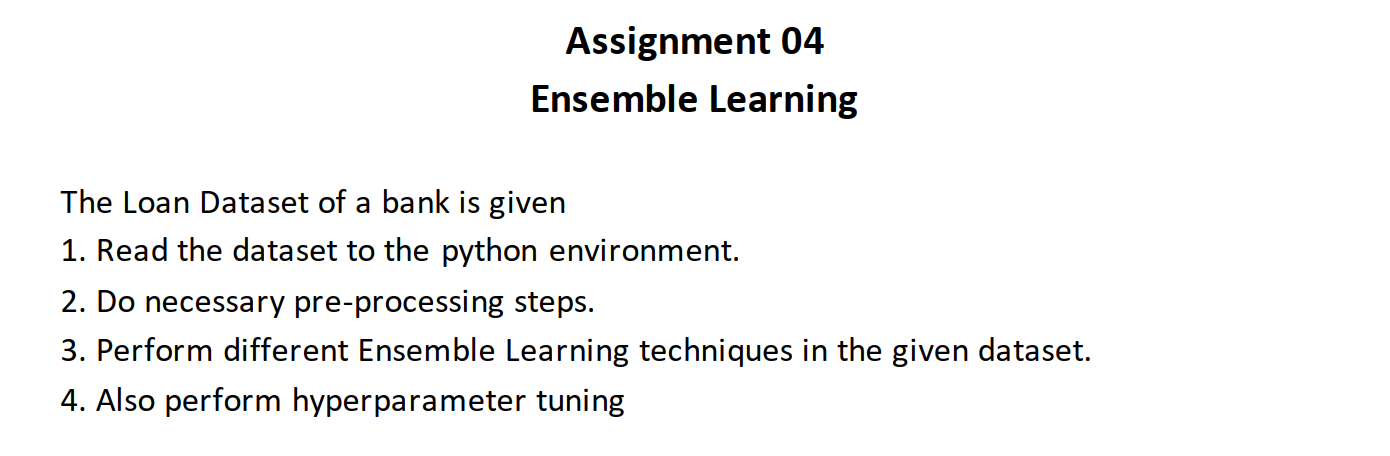

Dataset:https://drive.google.com/file/d/1xJo16ZdKbmmsqm80TMTaiPYxiN7Uu9OJ/view

Due date: 15/05/2025

---

# Importing modules

In [373]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing data and data overview


In [374]:
df=pd.read_csv('/content/train_loan.csv')
df.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [375]:
df.size

7982

In [376]:
df.shape

(614, 13)

13 columns

In [377]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [378]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [379]:
num_col=['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term', 'Credit_History']
num_col

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

5

In [380]:
cat_col=['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status']
cat_col

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

8

8 cat_col and 5 num_col

In [381]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [382]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [383]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


cat_col with missing values
- Gender
- Married
- Dependents
- Self_Employed

num_col with missing values
- LoadAmount
-Loan_Amount_term
- Credit_History

In [384]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
609,False
610,False
611,False
612,False


No duplication

# Data Preprocessing

### make a copy of the original dataset

In [385]:
df_cleaned=df.copy()

## Distribution of target column


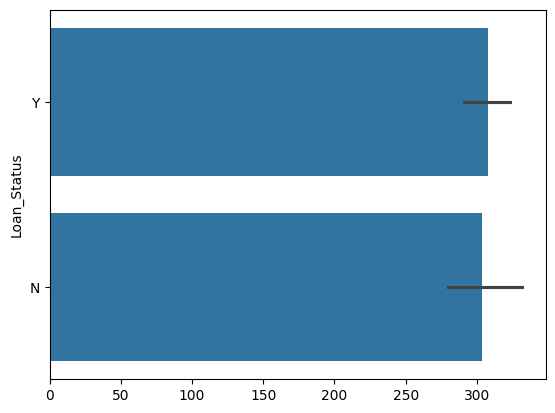

In [386]:
sns.barplot(df_cleaned['Loan_Status'])
plt.show()

## Distribution of num_col

## Univariate analysis of numerical colum

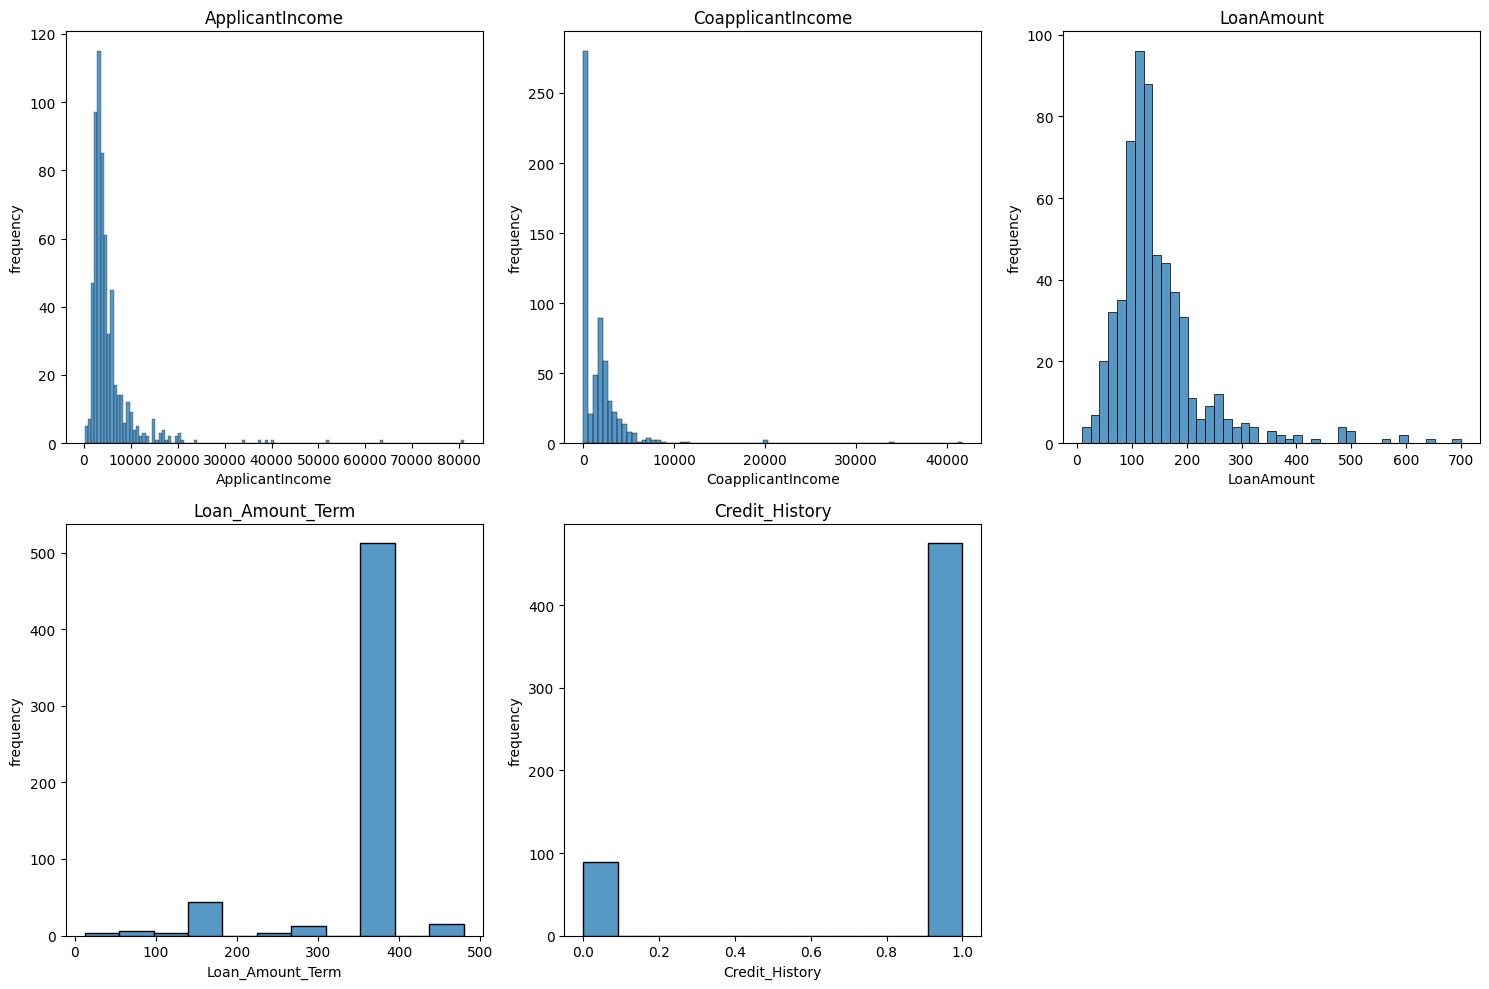

In [387]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_col,1):
  plt.subplot(2,3,i)
  sns.histplot(df_cleaned[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

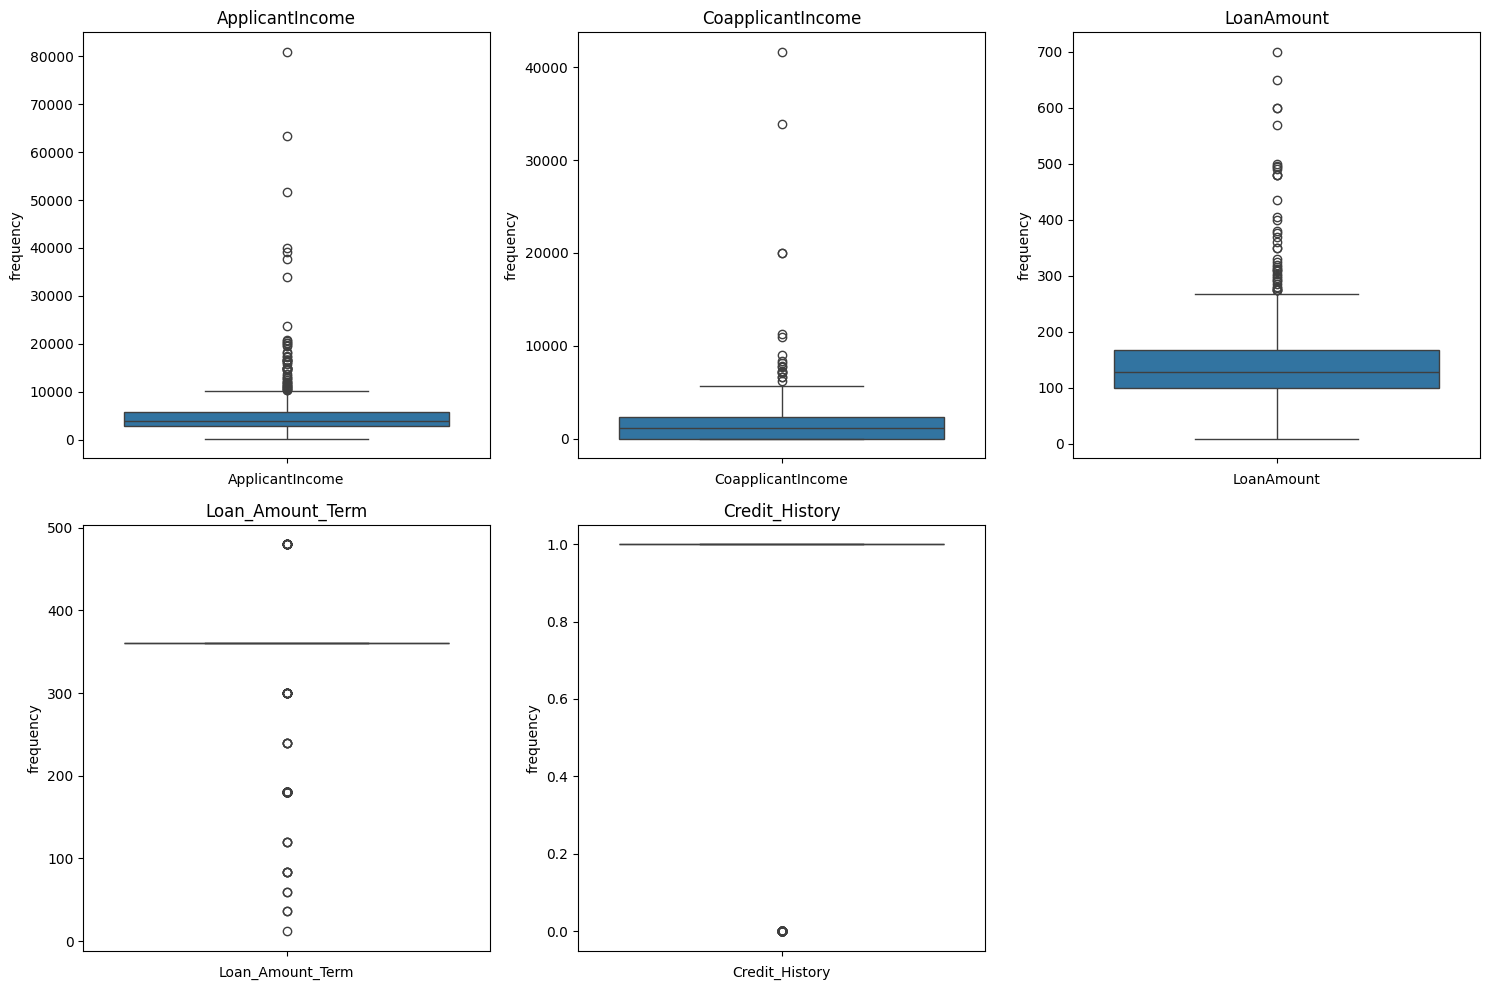

In [388]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_col,1):
  plt.subplot(2,3,i)
  sns.boxplot(df_cleaned[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

## Univariate analysis of categorical column

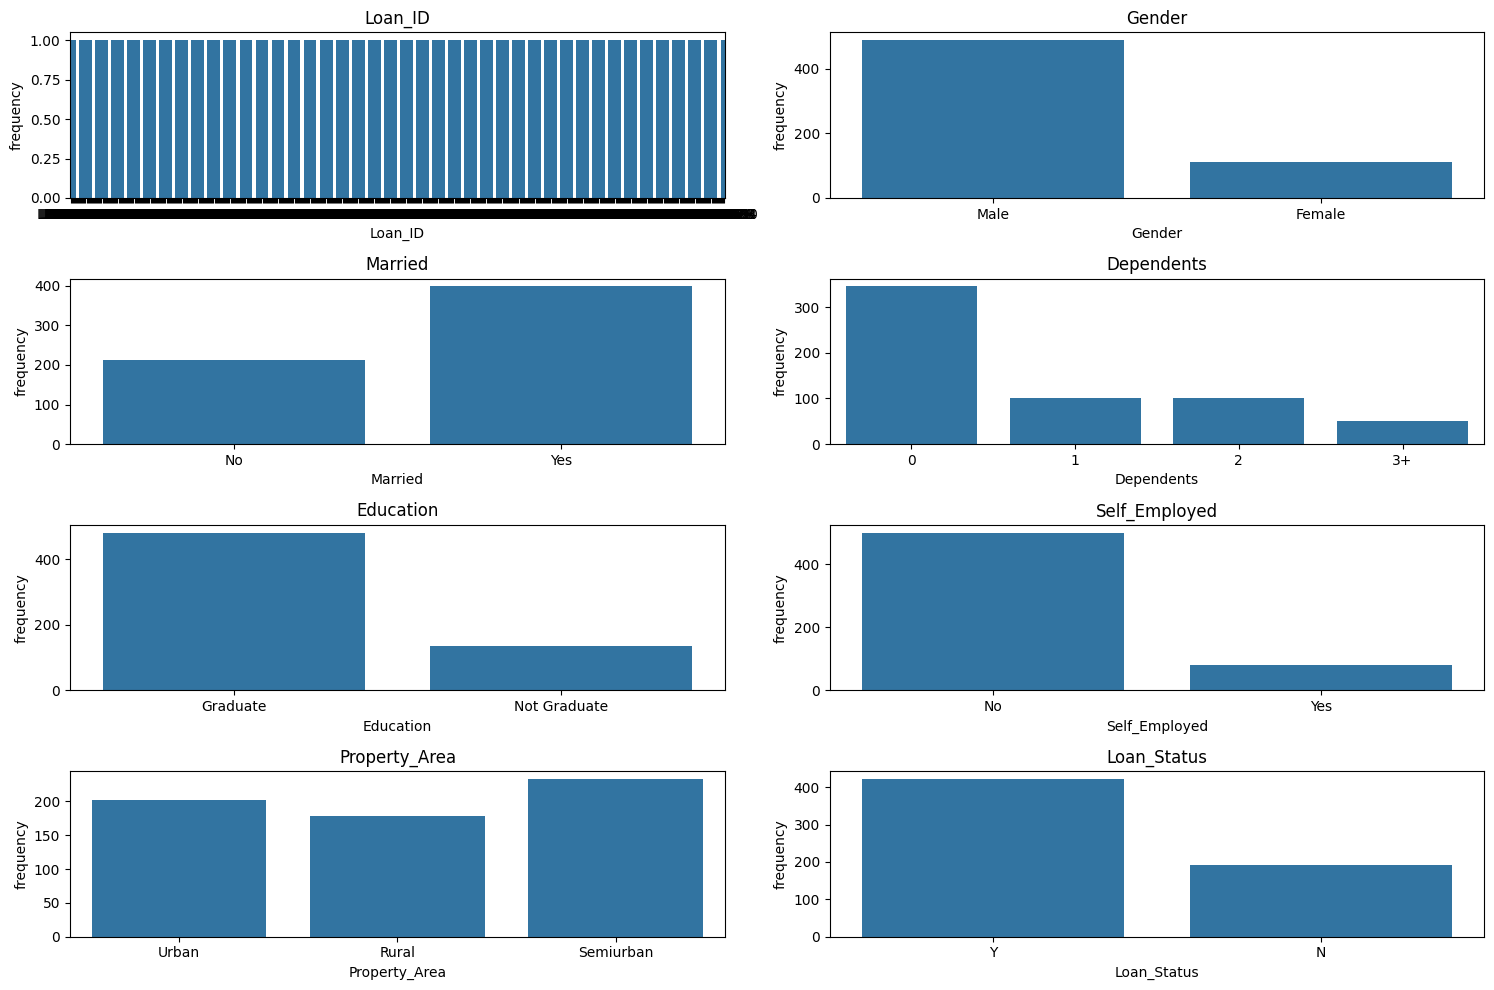

In [389]:
plt.figure(figsize=(15,10))
for i,col in enumerate(cat_col,1):
  plt.subplot(4,2,i)
  sns.countplot(x=df_cleaned[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

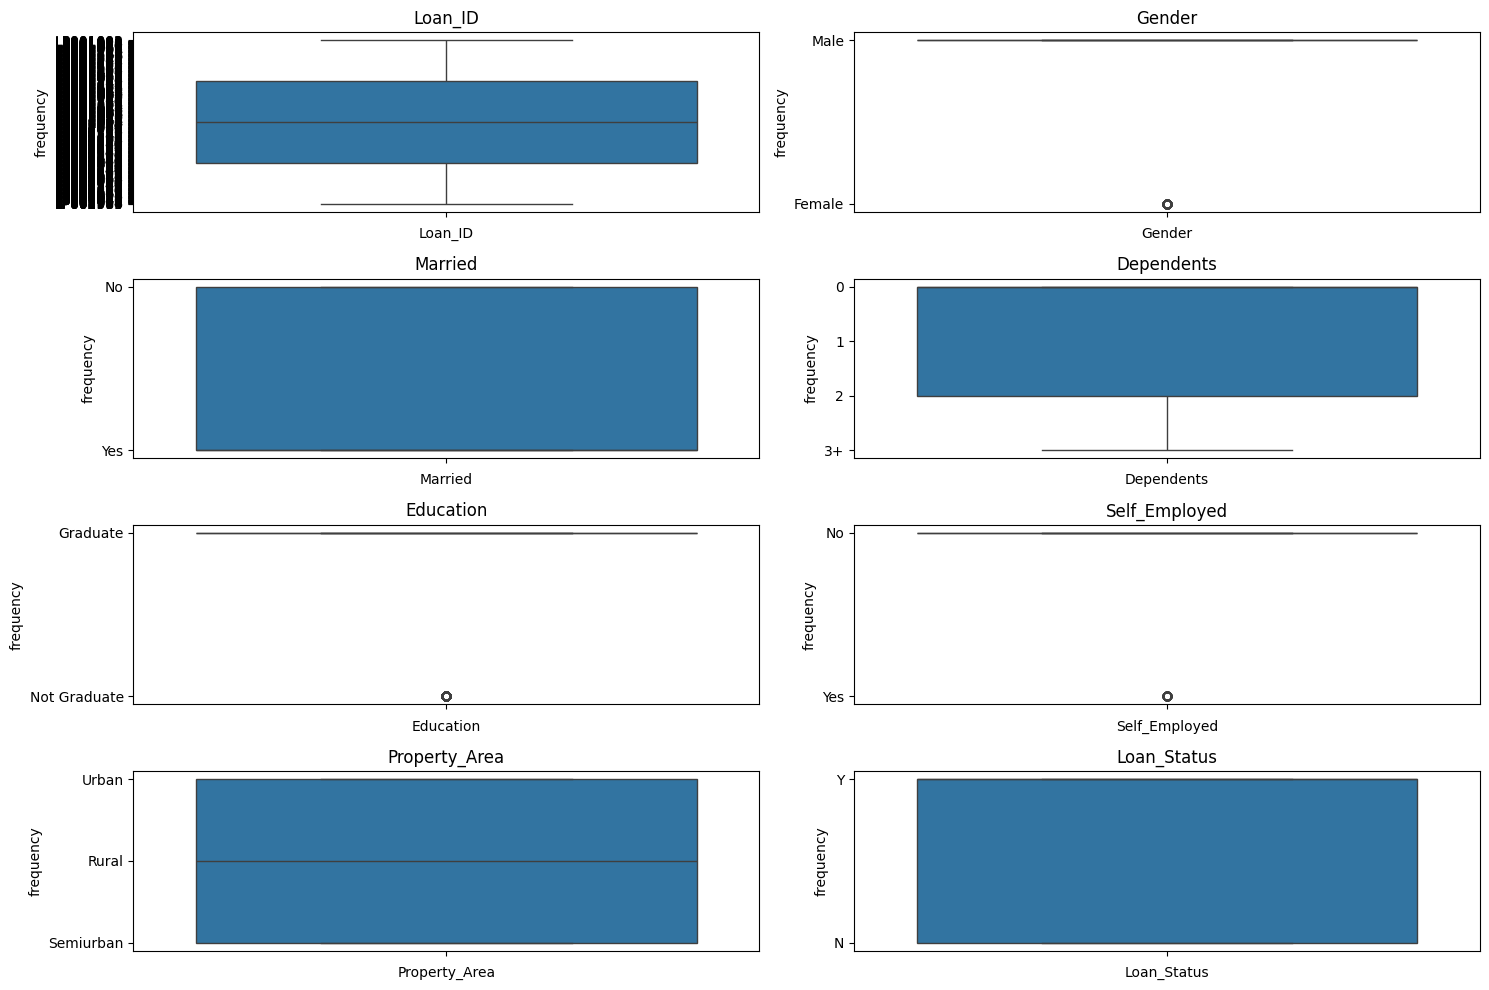

In [390]:
plt.figure(figsize=(15,10))
for i,col in enumerate(cat_col,1):
  plt.subplot(4,2,i)
  sns.boxplot(df_cleaned[col])
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel('frequency')

plt.tight_layout()
plt.show()

## Bivariate analysis of num_col

### Bivariate analysis between num_col vs cat target variable

In [391]:
num_col

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

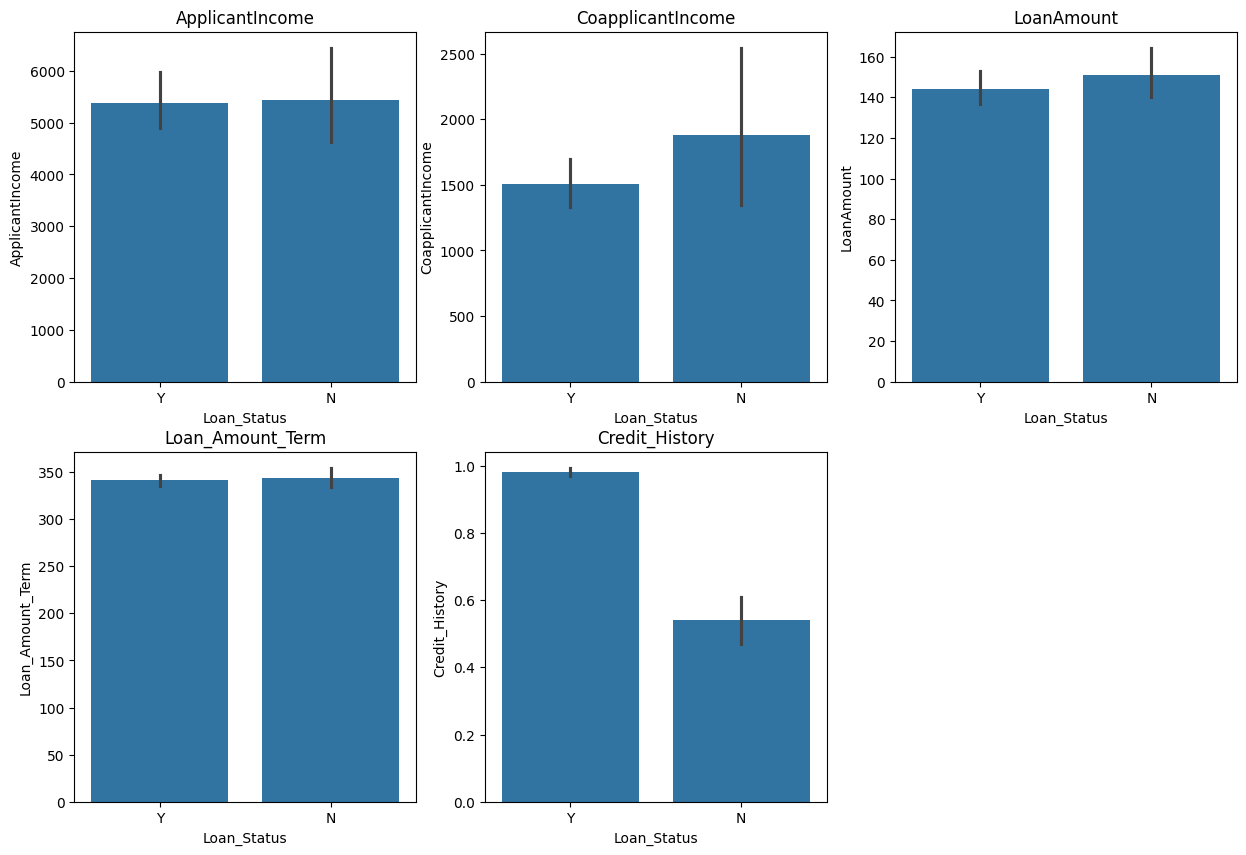

In [392]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_col,1):
  plt.subplot(2,3,i)
  sns.barplot(x=df_cleaned['Loan_Status'],y=df_cleaned[col])
  plt.title(col)

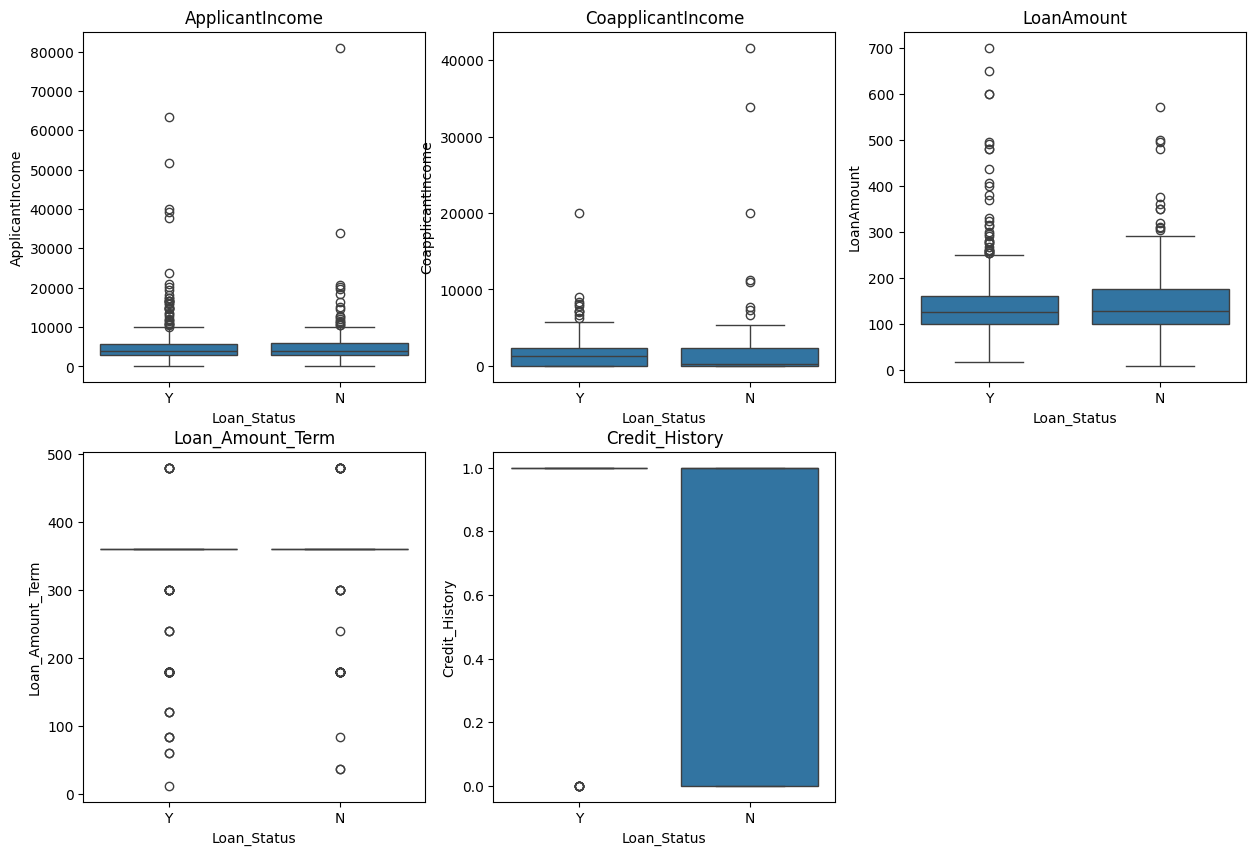

In [393]:
plt.figure(figsize=(15,10))
for i,col in enumerate(num_col,1):
  plt.subplot(2,3,i)
  sns.boxplot(x=df_cleaned['Loan_Status'],y=df_cleaned[col])
  plt.title(col)

## Bivariate analysis between cat_col vs target

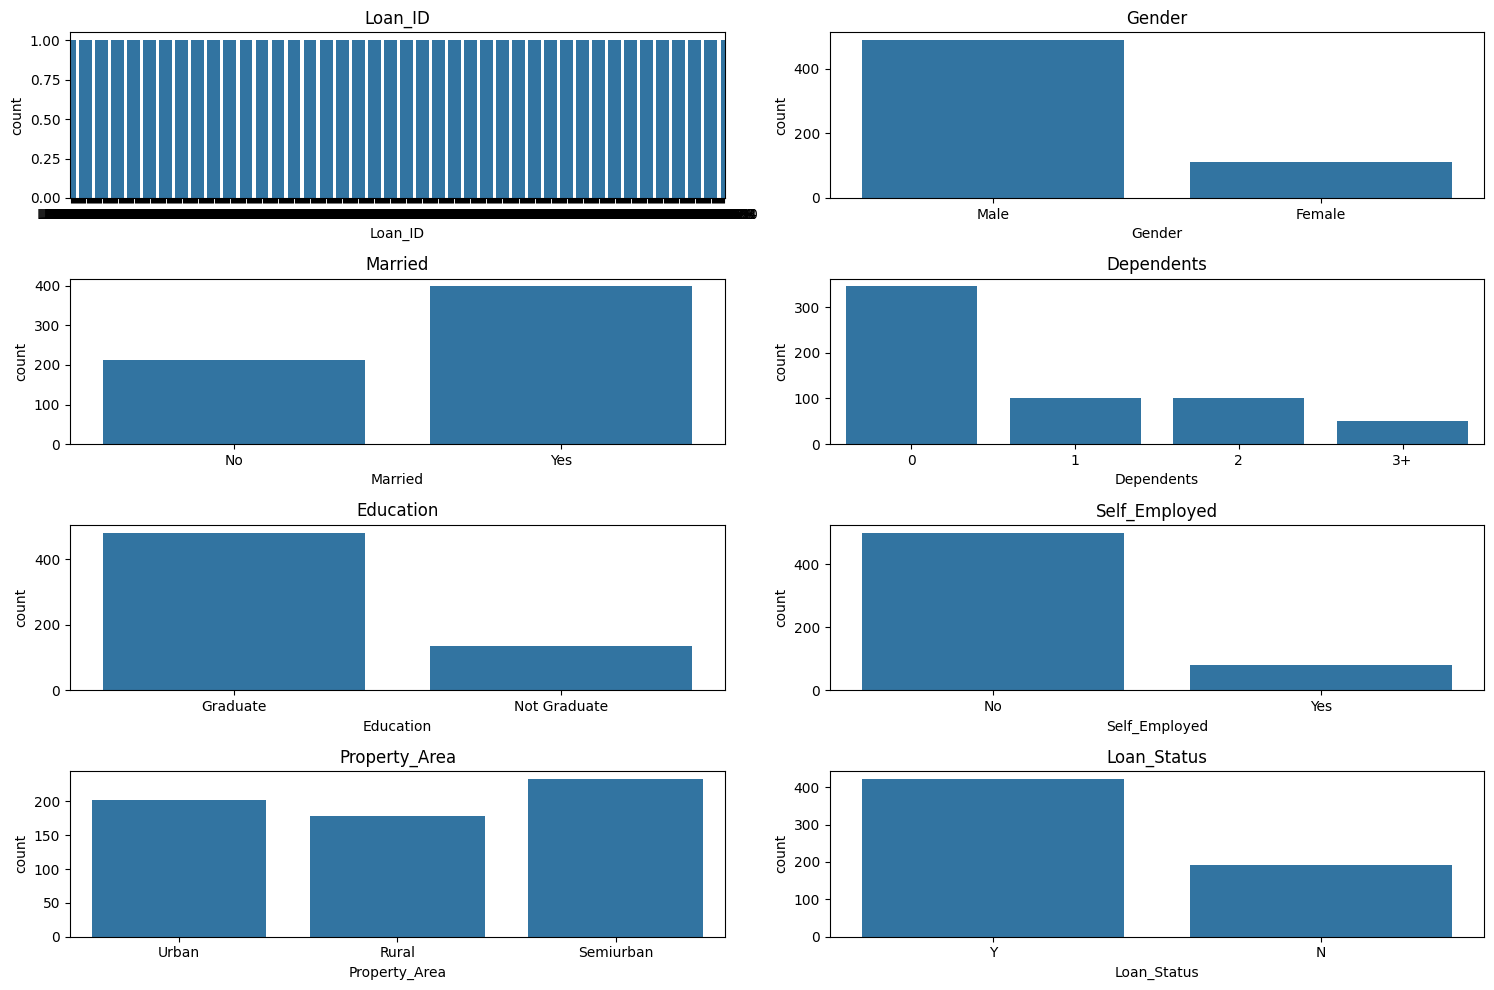

In [394]:
plt.figure(figsize=(15,10))
for i,col in enumerate(cat_col,1):
  plt.subplot(4,2,i)
  sns.countplot(x=df_cleaned[col])
  plt.title(col)
  plt.xlabel(col)


plt.tight_layout()
plt.show()

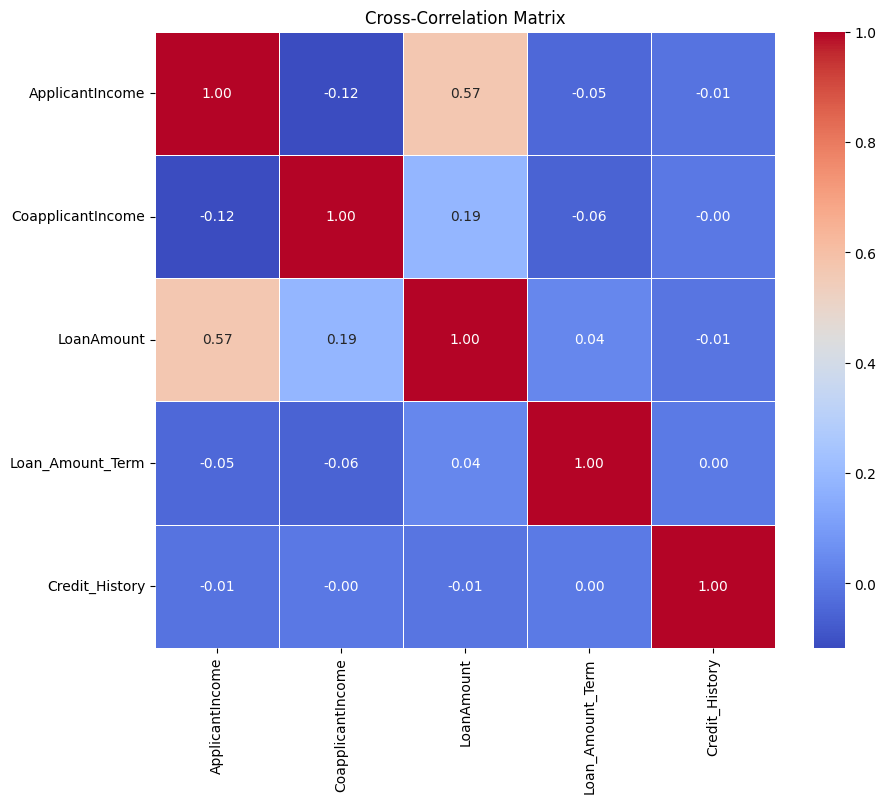

In [395]:
corr_matrix=df_cleaned[num_col].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Cross-Correlation Matrix")
plt.show()

## Filling categorical missing values

In [396]:
cat_col

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

cat_col with missing values
- Gender
- Married
- Dependents
- Self_Employed

In [397]:
df_cleaned['Gender'].value_counts()

,count
Gender,
Male,489
Female,112


In [398]:
df_cleaned['Married'].value_counts()

,count
Married,
Yes,398
No,213


In [399]:
df_cleaned['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [400]:
df_cleaned['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [401]:
df_cleaned['Gender'].fillna(df_cleaned['Gender'].mode()[0],inplace=True)
df_cleaned['Married'].fillna(df_cleaned['Married'].mode()[0],inplace=True)
df_cleaned['Dependents'].fillna(df_cleaned['Dependents'].mode()[0],inplace=True)
df_cleaned['Self_Employed'].fillna(df_cleaned['Self_Employed'].mode()[0],inplace=True)

<ipython-input-401-be5660595cd3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['Gender'].fillna(df_cleaned['Gender'].mode()[0],inplace=True)
<ipython-input-401-be5660595cd3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [402]:
df_cleaned.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## Filling num missing values

num_col with missing values
- LoadAmount
-Loan_Amount_term
- Credit_History

In [403]:
df_cleaned['LoanAmount'].value_counts()

,count
LoanAmount,
120.0,20
110.0,17
100.0,15
187.0,12
160.0,12
...,...
292.0,1
142.0,1
350.0,1


In [404]:
df_cleaned['Loan_Amount_Term'].value_counts()

,count
Loan_Amount_Term,
360.0,512
180.0,44
480.0,15
300.0,13
84.0,4
240.0,4
120.0,3
60.0,2
36.0,2


In [405]:
df_cleaned['Credit_History'].value_counts()

,count
Credit_History,
1.0,475
0.0,89


In [406]:
df_cleaned['LoanAmount'].fillna(df_cleaned['LoanAmount'].median(),inplace=True)
df_cleaned['Loan_Amount_Term'].fillna(df_cleaned['Loan_Amount_Term'].mode()[0],inplace=True)
df_cleaned['Credit_History'].fillna(df_cleaned['Credit_History'].mode()[0],inplace=True)


<ipython-input-406-ccbb3fef87e3>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['LoanAmount'].fillna(df_cleaned['LoanAmount'].median(),inplace=True)
<ipython-input-406-ccbb3fef87e3>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].metho

In [407]:
df_cleaned.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


# Encoding

In [408]:
df_cleaned.head(6)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y


In [409]:
df_cleaned['Gender'].value_counts()

,count
Gender,
Male,502
Female,112


In [410]:
df_cleaned['Married'].value_counts()

,count
Married,
Yes,401
No,213


In [411]:
df_cleaned['Self_Employed'].value_counts()

,count
Self_Employed,
No,532
Yes,82


In [412]:
df_cleaned['Dependents'].value_counts()

,count
Dependents,
0,360
1,102
2,101
3+,51


In [413]:
df_cleaned['Education'].value_counts()

,count
Education,
Graduate,480
Not Graduate,134


In [414]:
df_cleaned['Property_Area'].value_counts()

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


All categorical variables with two values can be encoded using binary transformation and others can be done using OneHOt Encoding

In [415]:
binary_col1=['Married','Self_Employed']
df_cleaned[binary_col1]=df_cleaned[binary_col1].replace({'Yes':1,'No':0})

<ipython-input-415-b24acb6f6ff4>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[binary_col1]=df_cleaned[binary_col1].replace({'Yes':1,'No':0})


In [416]:
binary_col2=['Gender']
df_cleaned[binary_col2]=df_cleaned[binary_col2].replace({'Male':1,'Female':0})

<ipython-input-416-c151707cb321>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[binary_col2]=df_cleaned[binary_col2].replace({'Male':1,'Female':0})


In [417]:
binary_col3=['Education']
df_cleaned[binary_col3]=df_cleaned[binary_col3].replace({'Graduate':1,'Not Graduate':0})

<ipython-input-417-79b1b54fa4c4>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[binary_col3]=df_cleaned[binary_col3].replace({'Graduate':1,'Not Graduate':0})


In [418]:
binary_col4=['Dependents']
df_cleaned[binary_col4]=df_cleaned[binary_col4].replace({'3+':3})

In [419]:
binary_col5=['Loan_Status']
df_cleaned[binary_col5]=df_cleaned[binary_col5].replace({'Y':1,'N':0})

<ipython-input-419-5ea7c3fe2485>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned[binary_col5]=df_cleaned[binary_col5].replace({'Y':1,'N':0})


###OneHot Encoding

In [420]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['Property_Area'])

In [421]:
df_cleaned.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001002,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,LP001003,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,LP001005,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,LP001006,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,LP001008,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,1,False,False,True
5,LP001011,1,1,2,1,1,5417,4196.0,267.0,360.0,1.0,1,False,False,True
6,LP001013,1,1,0,0,0,2333,1516.0,95.0,360.0,1.0,1,False,False,True
7,LP001014,1,1,3,1,0,3036,2504.0,158.0,360.0,0.0,0,False,True,False
8,LP001018,1,1,2,1,0,4006,1526.0,168.0,360.0,1.0,1,False,False,True
9,LP001020,1,1,1,1,0,12841,10968.0,349.0,360.0,1.0,0,False,True,False


## Data preparation for the model

In [422]:
from sklearn.model_selection import train_test_split
X=df_cleaned.drop(['Loan_ID','Loan_Status'],axis=1)
y=df_cleaned['Loan_Status']

### StandarScaler

In [423]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [424]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [425]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score,recall_score,f1_score,recall_score,classification_report


## Ensemble model

In [426]:
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='hard')

In [427]:
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))])

#Evaluating the model

## Random Forest

In [428]:
rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [429]:
y_pred_rf=rf.predict(X_test)
y_pred_rf

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [430]:
print(accuracy_score(y_test,y_pred_rf))
print(precision_score(y_test,y_pred_rf))
print(recall_score(y_test,y_pred_rf))
print(f1_score(y_test,y_pred_rf))

0.7723577235772358
0.7549019607843137
0.9625
0.8461538461538461


##Gradient Boost

In [431]:
gb.fit(X_train,y_train)

GradientBoostingClassifier(random_state=42)

In [432]:
y_pred_gb=rf.predict(X_test)
y_pred_gb

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [433]:
print(accuracy_score(y_test,y_pred_gb))
print(precision_score(y_test,y_pred_gb))
print(recall_score(y_test,y_pred_gb))
print(f1_score(y_test,y_pred_gb))

0.7723577235772358
0.7549019607843137
0.9625
0.8461538461538461


### Ensemble model

In [434]:
model=VotingClassifier(estimators=[('rf', rf), ('gb', gb)], voting='hard')

In [435]:
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.7560975609756098